In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.image import imread
from astropy.coordinates import SkyCoord
from astropy.coordinates import BarycentricTrueEcliptic
import astropy.units as u
from astropy.time import Time
from astropy.wcs import WCS
from tqdm import tqdm
from glob import glob
from functools import reduce
from sklearn.preprocessing import MinMaxScaler

from tess_asteroid_ml import *
from tess_asteroid_ml.utils import *
from tess_asteroid_ml.make_TESS_asteroid_db import *

import cartopy.crs as ccrs
from PIL import Image

/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
maglim = 21

edgefiles = [
    '/Users/jimartin/Work/TESS/tess_fullsky/edges_south.txt',
    '/Users/jimartin/Work/TESS/tess_fullsky/edges_north.txt',
]

secstarts = {1: 'Jul 2018', 2: 'Aug 2018', 3: 'Sep 2018', 4: 'Oct 2018',
             5: 'Nov 2018', 6: 'Dec 2018', 7: 'Jan 2019', 8: 'Feb 2019',
             9: 'Feb 2019', 10: 'Mar 2019', 11: 'Apr 2019', 12: 'May 2019',
             13: 'Jun 2019', 14: 'Jul 2019', 15: 'Aug 2019', 16: 'Sep 2019',
             17: 'Oct 2019', 18: 'Nov 2019', 19: 'Nov 2019', 20: 'Dec 2019',
             21: 'Jan 2020', 22: 'Feb 2020', 23: 'Mar 2020', 24: 'Apr 2020',
             25: 'May 2020', 26: 'Jun 2020', 27: 'Jul 2020', 28: 'Jul 2020',
             29: 'Aug 2020', 30: 'Sep 2020', 31: 'Oct 2020', 32: 'Nov 2020',
             33: 'Dec 2020', 34: 'Jan 2021', 35: 'Feb 2021', 36: 'Mar 2021',
             37: 'Apr 2021', 38: 'Apr 2021', 39: 'May 2021', 40: 'Jun 2021',
             41: 'Jul 2021', 42: 'Aug 2021', 43: 'Sep 2021', 44: 'Oct 2021',
             45: 'Nov 2021', 46: 'Dec 2021', 47: 'Dec 2021', 48: 'Jan 2022',
             49: 'Feb 2022', 50: 'Mar 2022', 51: 'Apr 2022', 52: 'May 2022',
             53: 'Jun 2022', 54: 'Jul 2022', 55: 'Aug 2022', 56: 'Sep 2022',
             57: 'Sep 2022', 58: 'Oct 2022', 59: 'Nov 2022', 60: 'Dec 2022',
             61: 'Jan 2023', 62: 'Feb 2023', 63: 'Mar 2023', 64: 'Apr 2023',
             65: 'May 2023', 66: 'Jun 2023', 67: 'Jul 2023', 68: 'Jul 2023',
             69: 'Aug 2023', 70: 'Sep 2023', 71: 'Oct 2023', 72: 'Nov 2023',
             73: 'Dec 2023', 74: 'Jan 2024', 75: 'Jan 2024', 76: 'Feb 2024',
             77: 'Mar 2024', 78: 'Apr 2024', 79: 'May 2024', 80: 'Jun 2024',
             81: 'Jul 2024', 82: 'Aug 2024', 83: 'Sep 2024', 84: "Oct 2024", 
             85: "Nov 2024", 86: "Dec 2024", 87: "Jan 2025", 88: "Feb 2025",
             89: "Mar 2025", 90: "Apr 2025", 91: "May 2025", 92: "Jun 2025",
             93: "Jun 2025", 94: "Jul 2025", 95: "Aug 2025", 96: "Sep 2025",}
secends = {1: 'Aug 2018', 2: 'Sep 2018', 3: 'Oct 2018', 4: 'Nov 2018',
           5: 'Dec 2018', 6: 'Jan 2019', 7: 'Feb 2019', 8: 'Feb 2019',
           9: 'Mar 2019', 10: 'Apr 2019', 11: 'May 2019', 12: 'Jun 2019',
           13: 'Jul 2019', 14: 'Aug 2019', 15: 'Sep 2019', 16: 'Oct 2019',
           17: 'Nov 2019', 18: 'Nov 2019', 19: 'Dec 2019', 20: 'Jan 2020',
           21: 'Feb 2020', 22: 'Mar 2020', 23: 'Apr 2020', 24: 'May 2020',
           25: 'Jun 2020', 26: 'Jul 2020', 27: 'Jul 2020', 28: 'Aug 2020',
           29: 'Sep 2020', 30: 'Oct 2020', 31: 'Nov 2020', 32: 'Dec 2020',
           33: 'Jan 2021', 34: 'Feb 2021', 35: 'Mar 2021', 36: 'Apr 2021',
           37: 'Apr 2021', 38: 'May 2021', 39: 'Jun 2021', 40: 'Jul 2021',
           41: 'Aug 2021', 42: 'Sep 2021', 43: 'Oct 2021', 44: 'Nov 2021',
           45: 'Dec 2021', 46: 'Dec 2021', 47: 'Jan 2022', 48: 'Feb 2022',
           49: 'Mar 2022', 50: 'Apr 2022', 51: 'May 2022', 52: 'Jun 2022',
           53: 'Jul 2022', 54: 'Aug 2022', 55: 'Sep 2022', 56: 'Sep 2022',
           57: 'Oct 2022', 58: 'Nov 2022', 59: 'Dec 2022', 60: 'Jan 2023',
           61: 'Feb 2023', 62: 'Mar 2023', 63: 'Apr 2023', 64: 'May 2023',
           65: 'Jun 2023', 66: 'Jul 2023', 67: 'Jul 2023', 68: 'Aug 2023',
           69: 'Sep 2023', 70: 'Oct 2023', 71: 'Nov 2023', 72: 'Dec 2023',
           73: 'Jan 2024', 74: 'Jan 2024', 75: 'Feb 2024', 76: 'Mar 2024',
           77: 'Apr 2024', 78: 'May 2024', 79: 'Jun 2024', 80: 'Jul 2024',
           81: 'Aug 2024', 82: 'Sep 2024', 83: 'Oct 2024', 84: "Oct 2024",
           85: "Oct 2024", 86: "Nov 2024", 87: "Dec 2024", 88: "Jan 2025",
           89: "Feb 2025", 90: "Mar 2025", 91: "Apr 2025", 92: "May 2025",
           93: "Jun 2025", 94: "Jun 2025", 95: "Jul 2025", 96: "Aug 2025",}

file_path = "https://tess.mit.edu/public/files/TESS_orbit_times.csv"
downlinks = pd.read_csv(file_path, comment="#")

# Sector 3 was used for testing ACS and downlink times are not accurate.
# Manual override using values from https://tess.mit.edu/public/files/TESS_FFI_observation_times.csv
downlinks.loc[
    np.logical_and(downlinks["Sector"] == 3, downlinks["Orbit"] == 13),
    ["Start of Orbit", "End of Orbit"],
] = ["2018-09-20 12:56:15", "2018-10-05 01:29:40"]
downlinks.loc[
    np.logical_and(downlinks["Sector"] == 3, downlinks["Orbit"] == 14),
    ["Start of Orbit", "End of Orbit"],
] = ["2018-10-05 03:29:40", "2018-10-17 21:17:58"]



In [4]:
def projection_param(hemisphere):

    if hemisphere == 'south':
        cenlon = 90.
        cenlat = -90.#-66.560708333333#
        projection = ccrs.AzimuthalEquidistant(central_longitude=cenlon, central_latitude=cenlat)    
        wrap = False
        title = "NASA TESS's View\nof the Southern\nHemisphere"
        min_lat, max_lat = -90, 0.
    
    elif hemisphere == 'north':
        cenlon = -90.
        cenlat = 90.#-66.560708333333#
        projection = ccrs.AzimuthalEquidistant(central_longitude=cenlon, central_latitude=cenlat)    
        wrap = False
        title = "NASA TESS's View\nof the Northern\nHemisphere"
        min_lat, max_lat = 0., 90.
    
    elif hemisphere == 'both-moll':
        cenlon = 0.
        cenlat = 0.
        galactic_coords = False
        if galactic_coords:
            cenlon += 180
        projection = ccrs.Mollweide(central_longitude=cenlon)
        wrap = True
        title = "NASA TESS's View\nof the Sky"
        min_lat, max_lat = -90., 90.

    elif hemisphere == 'both-plate':
        cenlon = 0.
        cenlat = 0.
        galactic_coords = False
        if galactic_coords:
            cenlon += 180
        projection = ccrs.PlateCarree(central_longitude=cenlon)
        wrap = True
        title = "NASA TESS's View\nof the Sky"
        min_lat, max_lat = -90., 90.

    else:
        projection = "rectilinear"
        cenlon = 0
        min_lat, max_lat = -90., 90.
        wrap = False

    return projection, cenlon, min_lat, max_lat, wrap

## Plot TESS static image

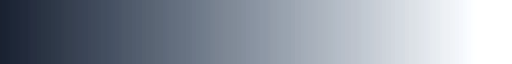

In [5]:
img = imread('bluecmap.png')
pic = img[:, 0, :]
img_cmap = colors.LinearSegmentedColormap.from_list('NASA_blue', pic[::-1, :], N=pic.shape[0])
img_cmap

In [6]:
title = "NASA TESS"
credit = "By Jorge Martinez-Palomera \n     Veselin Kostov & Ethan Kruse"

In [7]:
def plot_all_sky_mosaic(
    fig=None,
    ax=None, 
    projection=ccrs.Mollweide(central_longitude=0), 
    lognorm=False, 
    mission="all",
    title=False,
):
    if ax is None:
        fig = plt.figure(figsize=(50, 25))
        ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)

    ax.spines['geo'].set_linewidth(0)
    
    for edgefile in edgefiles:
        elat, elon = np.loadtxt(edgefile, unpack=True)
        plt.scatter(elon, elat, c='w', alpha=0.01, zorder=-5,
                    marker='.', s=1, transform=ccrs.PlateCarree())
    if title:
        ax.text(0.025, 0.96, "NASA TESS \nAll-Sky View", transform=fig.transFigure,
                 ha='left', va='top', multialignment='left',
                 fontsize=70, fontweight="semibold")
        ax.text(0.025, 0.02, credit, transform=fig.transFigure,
                 ha='left', va='bottom', multialignment='left',
                 fontsize=40)

    pkl_list = sorted(glob(f"data/ffi_allsky/TESS_full_sky_Cycle_*_bin4*.pkl"))
    if mission == "all":
        pkl_list = pkl_list
    elif mission == "primary":
        pkl_list = pkl_list[:2]
    elif mission == "ex-1":
        pkl_list = pkl_list[2:5]
    elif mission == "ex-2":
        pkl_list = pkl_list[5:]

    for pkf in tqdm(pkl_list, total=len(pkl_list), desc="Plotting Cycle"):
        pkl = pd.read_pickle(pkf)
        if lognorm:
            cnorm = colors.LogNorm(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
        else:
            cnorm = colors.Normalize(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
    
        for lon, lat, flux in zip(pkl["lon"], pkl["lat"], pkl["data"]):
            
            lmin = (((cenlon - 178) + 180) % 360) - 180
            lmax = (((cenlon + 178) + 180) % 360) - 180
            wlon = ((lon - cenlon + 180) % 360) - 180
            if wrap and (lon.max() > lmax) and (lon.min() < lmin):
                bad = ((np.abs(wlon[:-1, :-1] - wlon[:-1, 1:]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, :-1]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, 1:]) > 355.))
                masked_flux = np.ma.masked_where(bad, flux)
                ax.pcolormesh(
                    lon, lat, masked_flux, 
                    norm=cnorm, alpha=1, cmap=img_cmap,
                    transform=ccrs.PlateCarree(),
                )
            else:
                ax.pcolormesh(
                    lon, lat, flux, 
                    norm=cnorm, alpha=1, cmap=img_cmap,
                    transform=ccrs.PlateCarree(),
                )
    return ax

+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs


Plotting Cycle: 100%|████████████████████████████████████████████████████████████| 2/2 [00:06<00:00,  3.25s/it]


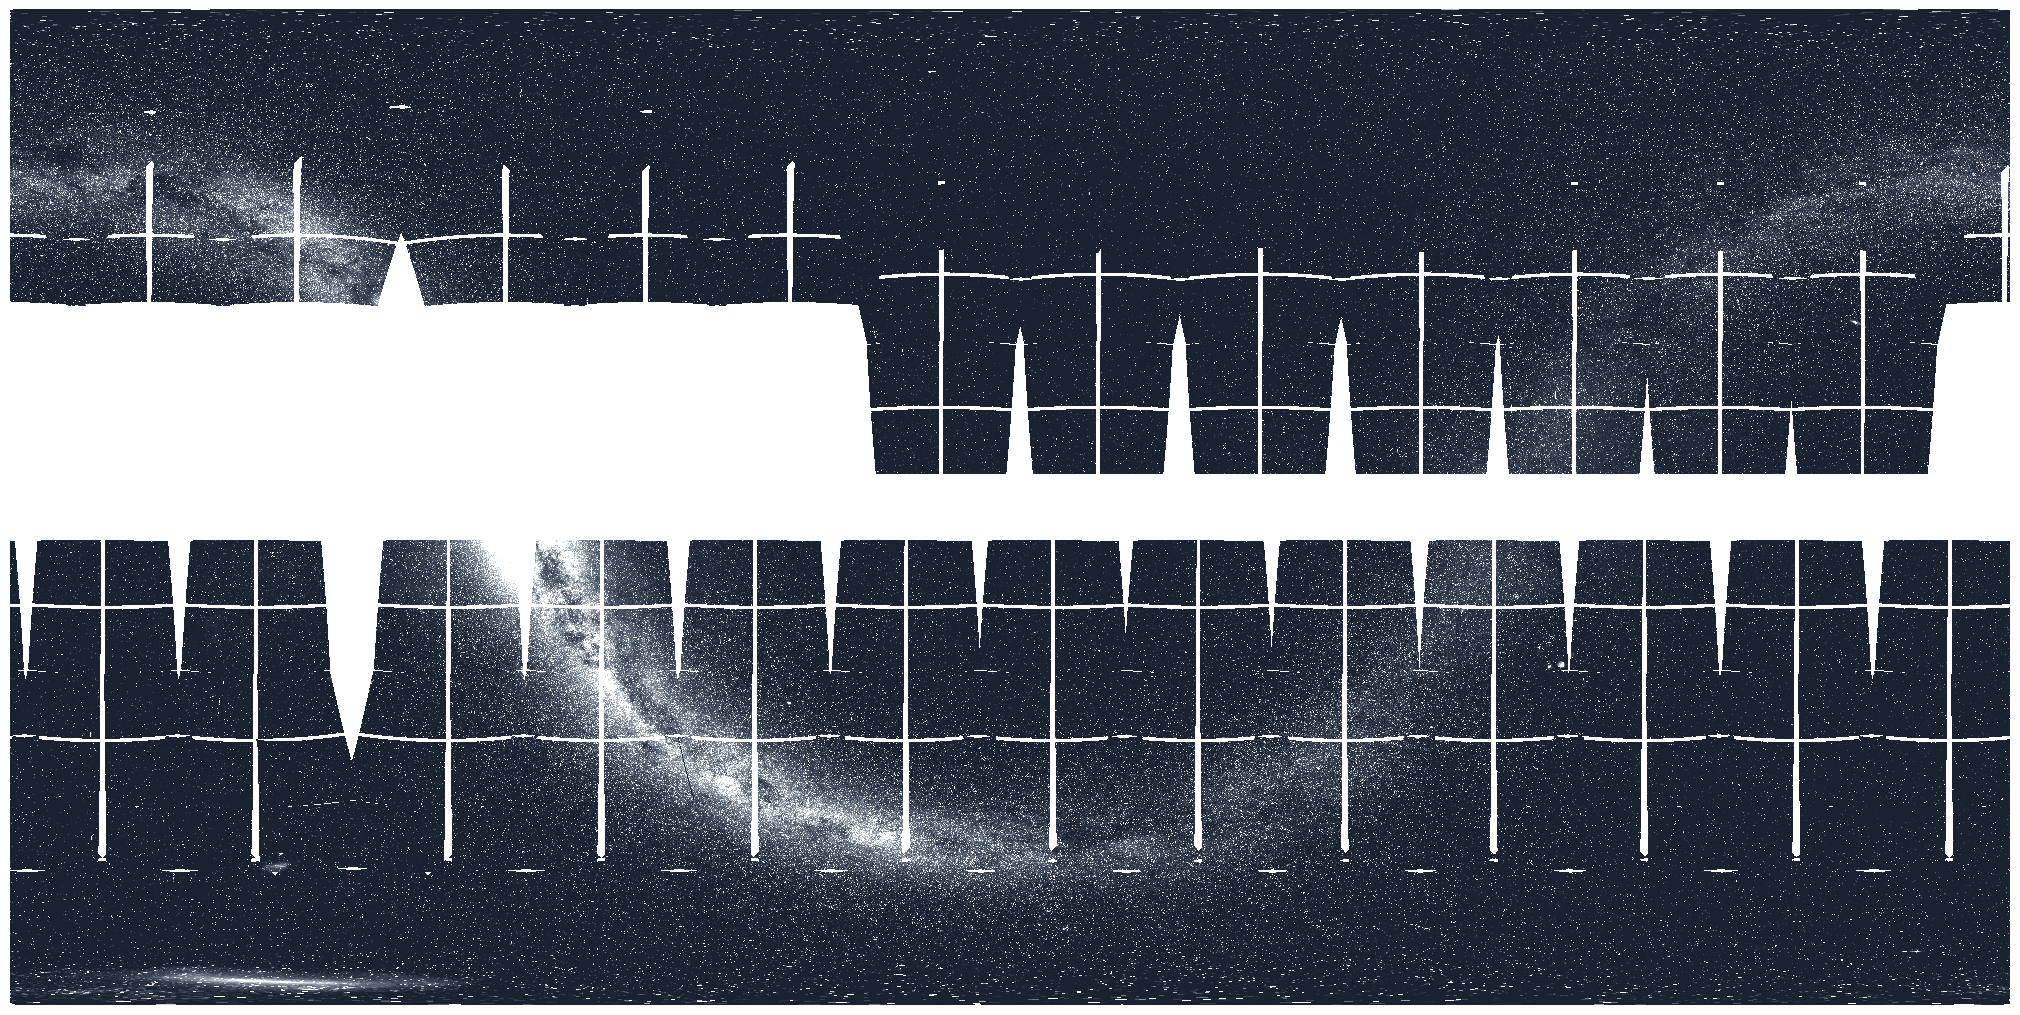

In [8]:
projection, cenlon, min_lat, max_lat, wrap = projection_param("both-plate")
print(projection)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)
plot_all_sky_mosaic(fig=fig, ax=ax, lognorm=False, mission="primary", projection=projection)
# plt.savefig(
#     f"./figures/animation/fixed_bkg/tess_all-sky_mosaic_primary_linear.png", 
#     transparent=True, format="png", bbox_inches="tight", dpi=200
# )
plt.show()

## Plot TESS single sector

In [9]:
def plot_sector_ffi(
    fig=None,
    ax=None, 
    projection="rectilinear", 
    lognorm=False, 
    sector=1,
    title=False,
):
    if ax is None:
        fig = plt.figure(figsize=(20, 5))
        ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)

    if title:
        ax.text(0.025, 0.96, f"NASA TESS\nSector {sector}", transform=fig.transFigure,
                 ha='left', va='top', multialignment='left',
                 fontsize=70, fontweight="semibold")
        ax.text(0.025, 0.02, credit, transform=fig.transFigure,
                 ha='left', va='bottom', multialignment='left',
                 fontsize=40)

    cycle = ((sector-1) // 13) + 1
    pkf = sorted(glob(f"data/ffi_allsky/TESS_full_sky_Cycle_{cycle}_bin4*.pkl"))
    if len(pkf) == 0:
        raise FileExistsError(f"Pickle file for Sector {sector} Cycle {cycle} does not exist")

    pkl = pd.read_pickle(pkf[0])
    
    nccds = 16
    ffi_idx_i = (sector - 1) * nccds
    ffi_idx_f = ffi_idx_i + nccds
        
    if lognorm:
        cnorm = colors.LogNorm(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
    else:
        cnorm = colors.Normalize(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
    
    for idx, (lon, lat, flux) in enumerate(zip(pkl["lon"][ffi_idx_i : ffi_idx_f], 
                              pkl["lat"][ffi_idx_i : ffi_idx_f], 
                              pkl["data"][ffi_idx_i : ffi_idx_f]
                              )):
        if projection == "rectilinear":
            raise NotImplementedError
        else:
            lmin = (((cenlon - 178) + 180) % 360) - 180
            lmax = (((cenlon + 178) + 180) % 360) - 180
            wlon = ((lon - cenlon + 180) % 360) - 180
            if wrap and (lon.max() > lmax) and (lon.min() < lmin):
                bad = ((np.abs(wlon[:-1, :-1] - wlon[:-1, 1:]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, :-1]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, 1:]) > 355.))
                masked_flux = np.ma.masked_where(bad, flux)
                ax.pcolormesh(
                    lon, lat, masked_flux, 
                    norm=cnorm, alpha=1, cmap=img_cmap,
                    transform=ccrs.PlateCarree(),
                )
            else:
                ax.pcolormesh(
                    lon, lat, flux, 
                    norm=cnorm, alpha=1, cmap=img_cmap,
                    transform=ccrs.PlateCarree(),
                )
    return ax

+proj=aeqd +ellps=WGS84 +lon_0=90.0 +lat_0=-90.0 +x_0=0.0 +y_0=0.0 +no_defs +type=crs


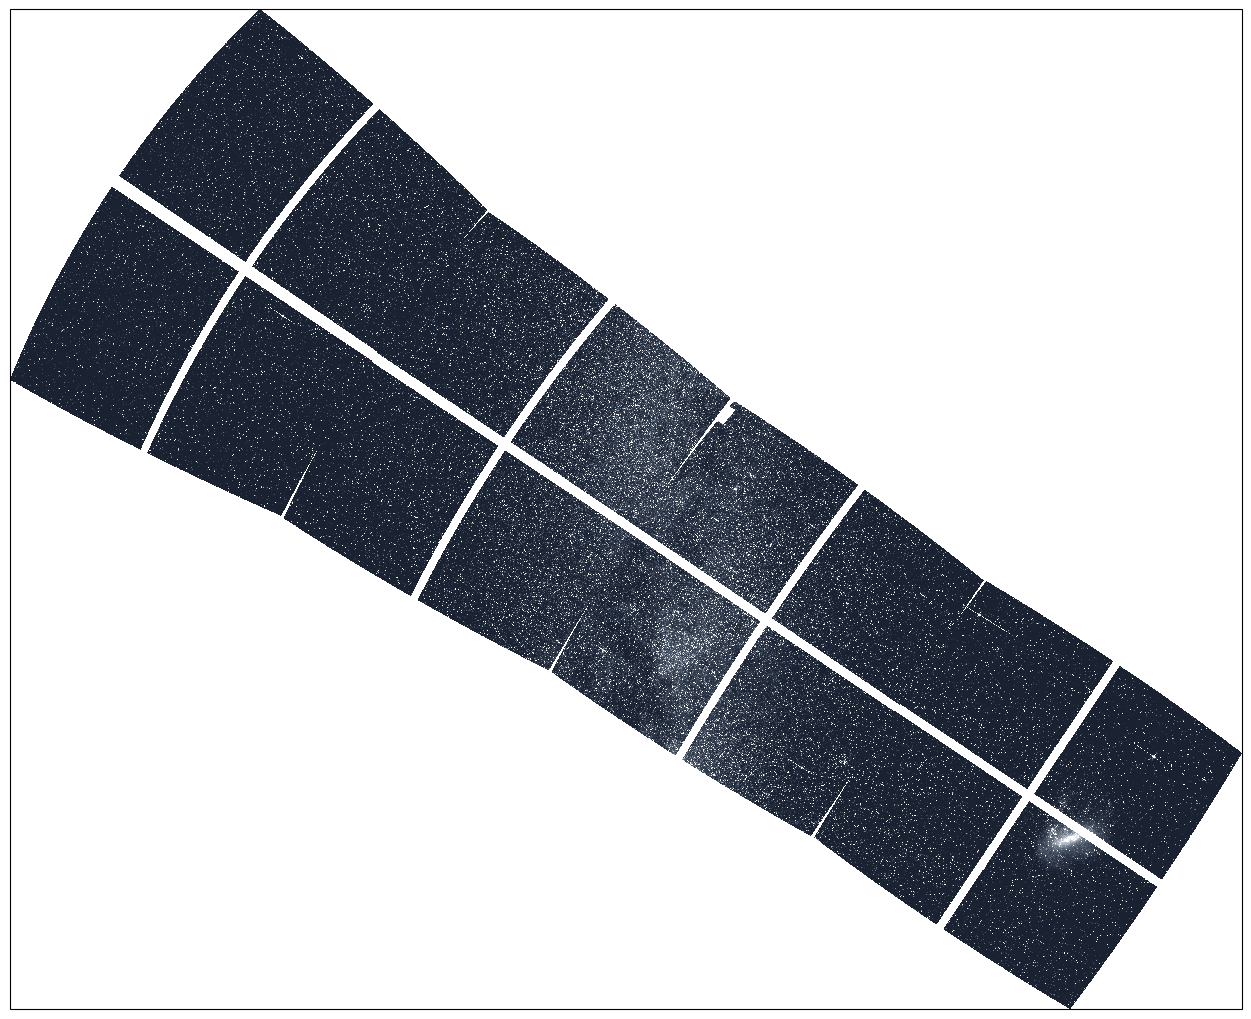

In [164]:
projection, cenlon, min_lat, max_lat, wrap = projection_param("south")
print(projection)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)
plot_sector_ffi(fig=fig, ax=ax, 
                lognorm=False, 
                sector=8, 
                projection=projection)
# plt.savefig(
#     f"./figures/animation/fixed_bkg/tess_all-sky_mosaic_primary_linear.png", 
#     transparent=True, format="png", bbox_inches="tight", dpi=200
# )
plt.show()

## Compute Asteroid tracks from data base

In [10]:
def get_asteroid_tracks_df(sector=1, step=1.):
    sec_ff = sorted(glob(f"{os.path.dirname(PACKAGEDIR)}/data/jpl/tracks/sector{sector:04}/"
                                  f"tess-ffi_s{sector:04}-0-0_*_hires.feather"))
    
    df = downlinks.query(f"Sector == {sector}")
    tstart = Time(df["Start of Orbit"].values[0], scale="utc", format="iso")
    tstop = Time(df["End of Orbit"].values[-1], scale="utc", format="iso")
    time_array = np.arange(tstart.jd, tstop.jd, step)
    
    pred_pos_lat = pd.DataFrame(columns=time_array)
    pred_pos_lon = pd.DataFrame(columns=time_array)
    pred_vmag = pd.DataFrame(columns=time_array)
    
    track_color= {}
        
    for k, ff in tqdm(enumerate(sec_ff), total=len(sec_ff), desc=f"Sector {sector:02}"):
        name = os.path.basename(ff)[19:-14]
        aux = pd.read_feather(ff)
        # step = len(aux) // 27 - 1 if len(aux) > 100 else 4
        if aux.vmag.mean() < maglim:
            icrs = SkyCoord(ra=aux.ra, dec=aux.dec, frame='icrs', unit='deg')
            ecliptic = icrs.transform_to(BarycentricTrueEcliptic)
            lat = ecliptic.lat.value * 1
            lon = ecliptic.lon.value * 1
            lon -= 180.
            lon *= -1.
            tr_lat = np.interp(time_array, aux.time, lat, left=np.nan, right=np.nan)
            tr_lon = np.interp(time_array, aux.time, lon, left=np.nan, right=np.nan)
            tr_vmag = np.interp(time_array, aux.time, aux.vmag.values, left=np.nan, right=np.nan)
            pred_pos_lat.loc[name] = tr_lat
            pred_pos_lon.loc[name] = tr_lon
            pred_vmag.loc[name] = tr_vmag
            if name not in track_color.keys():
                track_color[name] = plt.cm.tab20(np.random.randint(0,20))
        else:
            continue
    pred_pos_lat.to_csv(f"./data/ffi_allsky/asteroid_tracks_sector{sector:03}_1d_lat.csv")
    pred_pos_lon.to_csv(f"./data/ffi_allsky/asteroid_tracks_sector{sector:03}_1d_lon.csv")
    pred_vmag.to_csv(f"./data/ffi_allsky/asteroid_tracks_sector{sector:03}_1d_vmag.csv")

def merge_tracks_df(maglim=19, sectors=np.arange(1, 27)):
    all_lat = []
    all_lon = []
    all_vmag = []
    sector_array = []
    counts = []
    for sec in sectors:
        pred_pos_lat = pd.read_csv(
            f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_lat.csv", index_col=0
        )
        
        pred_pos_lon = pd.read_csv(
            f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_lon.csv", index_col=0
        )
        average_mag = pd.read_csv(
            f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_vmag.csv", index_col=0
        )
        mask = average_mag.mean(axis=1) <= maglim
        all_lat.append(pred_pos_lat[mask])
        all_lon.append(pred_pos_lon[mask])
        all_vmag.append(average_mag[mask])
        sector_array.extend([sec]*pred_pos_lat.shape[1])
        counts.append(mask.sum())
    sector_array = np.array(sector_array)
    counts = np.array(counts)

    all_lat = reduce(lambda left, right: pd.merge(
        left, right, left_index=True, right_index=True, how='outer'
    ), all_lat)
    all_lon = reduce(lambda left, right: pd.merge(
        left, right, left_index=True, right_index=True, how='outer'
    ), all_lon)
    all_vmag = reduce(lambda left, right: pd.merge(
        left, right, left_index=True, right_index=True, how='outer'
    ), all_vmag)

    return all_lat, all_lon, all_vmag, counts

In [165]:
get_asteroid_tracks_df(sector=8, step=0.1)

Sector 08: 100%|████████████████████████████████████████████████████████| 19383/19383 [02:40<00:00, 120.84it/s]


In [11]:
sector = [8]
all_lat, all_lon, all_vmag, counts = merge_tracks_df(sectors=sector)
time_array = all_lat.columns.values
all_lat.shape, all_lon.shape, all_vmag.shape, time_array.shape

((1096, 247), (1096, 247), (1096, 247), (247,))

## Plot frames with asteroid positions

### Use Vmag as color map and marker size

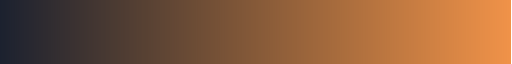

In [12]:
img = imread('BlueOrange.png')
pic = img[:, 0, :]
trk_cmap = colors.LinearSegmentedColormap.from_list('NASA_blue-orange', pic, N=pic.shape[0])
trk_cmap

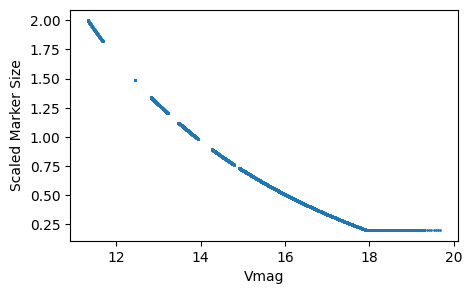

In [30]:
scaler = MinMaxScaler(feature_range=(0,2), clip=False)

ms = all_vmag.copy().values
aux = scaler.fit_transform(np.atleast_2d(1/ms[np.isfinite(ms)]**2).T, )
ms[np.isfinite(ms)] = aux.ravel()
ms[ms <= 0.2] = 0.2

plt.figure(figsize=(5,3))
plt.scatter(all_vmag.values, ms, s=1)
plt.xlabel("Vmag")
plt.ylabel("Scaled Marker Size")
plt.show()

### Option to fade tracks after N days

In [31]:
def calculate_alpha(current_time, decay_window=1, power=3.0):
    """
    Returns an array of alpha values for every time step from t=0 to t=current_time.
    
    Parameters:
    - current_time (int): The current step of the simulation (e.g., 50).
    - decay_window (int): How far back the trace should last (e.g., 10).
    - power (float): 1.0 is linear. Higher values (e.g., 3.0) make the trace 
                     faint for longer and then "quickly increase" to 1.
    
    Returns:
    - np.array: Array of alpha values between 0.0 and 1.0. 
                Index 0 corresponds to time=0.
    """
    
    # 1. Generate the timeline array: [0, 1, 2, ..., current_time]
    times = np.arange(current_time + 1)
    
    # 2. Calculate the "age" of each time step relative to now
    # If current_time is 50, time 50 has age 0, time 40 has age 10.
    ages = current_time - times
    
    # 3. Normalize the age into a 0.0 - 1.0 score
    # We want 1.0 when age is 0 (now), and 0.0 when age is decay_window.
    scores = (decay_window - ages) / decay_window
    
    # 4. Clip the scores to remove negative values (older than window)
    # and ensure nothing exceeds 1.0.
    scores = np.clip(scores, 0, 1)
    
    # 5. Apply the power curve to satisfy "quickly increase" requirement
    alphas = np.power(scores, power)
    
    return alphas

### Make frames

100%|████████████████████████████████████████████████████████████████████████| 247/247 [15:24<00:00,  3.74s/it]


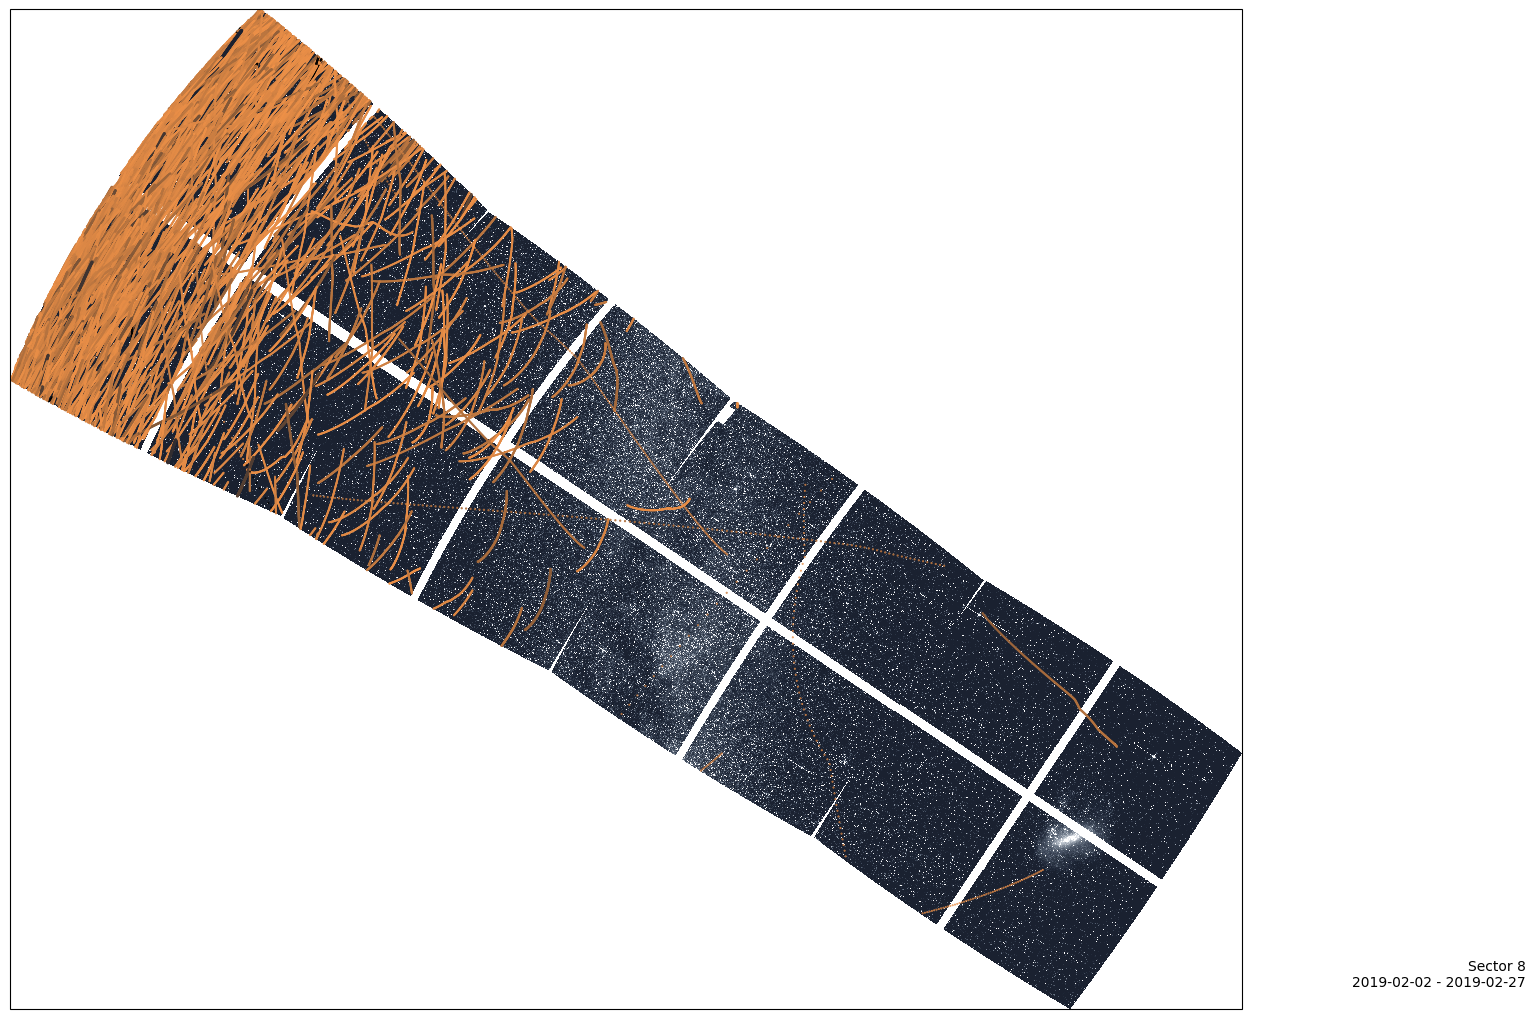

In [32]:
sector = 8
isot0 = Time(time_array[0], scale="utc", format="jd")
new_time = False

# plot background FFI
projection, cenlon, min_lat, max_lat, wrap = projection_param("south")
fig = plt.figure(figsize=(20, 10))
ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)
plot_sector_ffi(fig=fig, ax=ax, 
                lognorm=False, 
                sector=sector, 
                projection=projection)

for tdx in tqdm(range(0, len(time_array)), total=len(time_array)):  

    # cnts = ax.text(
    #         0.95, 0.96, "", transform=fig.transFigure, 
    #         ha='right', va='top', multialignment='right',
    #         fontsize=40,
    #     )

    alpha = calculate_alpha(tdx, decay_window=3., power=3)

    ax.scatter(
        all_lon.values[:, tdx], 
        all_lat.values[:, tdx], 
        c=all_vmag.values[:, tdx],
        cmap=trk_cmap,
        # c="tab:orange",
        s=ms[:, tdx], 
        rasterized=True, 
        transform=ccrs.PlateCarree(),
        alpha=1,
    )
    sectxt = f"Sector {sector}"
    isotf = Time(time_array[tdx], scale="utc", format="jd")
    sectxt = f"{sectxt}\n{isot0.iso[:10]} - {isotf.iso[:10]}"
    if new_time:
        date.remove()
    date = ax.text(
        0.95, 0.02, sectxt, transform=fig.transFigure, 
        ha='right', va='bottom', multialignment='right',
        fontsize=10,
    )
    # counts_cum = counts[:sec].sum()
    # astertxt = f"{counts_cum} Asteroids \nV < {maglim}"
    # cnts.remove()
    # cnts = ax.text(
    #     0.95, 0.96, astertxt, transform=fig.transFigure, 
    #     ha='right', va='top', multialignment='right',
    #     fontsize=50,
    # )

    plt.savefig(f"./figures/animation/fixed_bkg/tess_all-sky_sector_{sector}_tracks_{tdx:03}.png", 
                transparent=False, format="png", bbox_inches="tight", dpi=200)
    new_time = True
    # plt.close()

    # if tdx == 2: break
    
    # plt.show()

In [26]:
def make_gif_from_pngs(file_paths, output_gif_path, duration_ms=100, loop_count=0):
    """
    Creates an animated GIF from all PNG files in a specified folder.

    :param frame_folder: The path to the folder containing PNG images.
    :param output_gif_path: The filename for the output GIF (e.g., 'animation.gif').
    :param duration_ms: Duration of each frame in milliseconds (default 100ms).
    :param loop_count: The number of loops (0 means infinite loop).
    """

    if not file_paths:
        print(f"No PNG files found in {frame_folder}")
        return

    # Open all images using a generator for memory efficiency
    images = (Image.open(f) for f in file_paths)
    
    # Extract the first image to use as the base for saving
    first_frame = next(images)
    
    # Save as an animated GIF
    first_frame.save(
        fp=output_gif_path,
        format='GIF',
        append_images=images,
        save_all=True,  # Mandatory for saving animations
        duration=duration_ms,
        loop=loop_count,
        compress_level=1 # Optional: adjust compression
    )
    print(f"Successfully created GIF: {output_gif_path}")

In [33]:
file_paths = sorted(glob(f"./figures/animation/fixed_bkg/tess_all-sky_sector_{sector}_tracks_*.png"))
print(len(file_paths))

make_gif_from_pngs(
    file_paths=file_paths,
    output_gif_path=f"./figures/animation/fixed_bkg/tess_all-sky_sector_{sector}_tracks.gif",
    duration_ms=30, # 10 frames per second (1000ms / 100ms = 10)
    loop_count=0 # Infinite loop
)

247
Successfully created GIF: ./figures/animation/fixed_bkg/tess_all-sky_sector_8_tracks.gif
